In [1]:
import keras
print(keras.__version__)

2.9.0


In [ ]:
import os
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import tensorflow as tf
#libraries for building the model
from tensorflow.keras.layers import BatchNormalization, Conv2D,MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping




# Converting all the audio files into the .wav format
import soundfile as sf
import noisereduce as nr
from pydub import AudioSegment # will convert the format

from tensorflow.image import resize

import subprocess
import os
import sys
from spleeter.separator import Separator
import shutil

c:\Users\Suraj\Desktop\Projects\Indian_Music_Genre_Classifier\hindi_music\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = tf.keras.models.load_model("Multi_input_CNN_v2.keras")

In [ ]:
def spleeter_conversion(input_path, output_path):
    # 1. THE FORCE: Ensure Global FFmpeg
    global_ffmpeg_path = r"C:\ffmpeg\bin"
    os.environ["PATH"] = global_ffmpeg_path + os.pathsep + os.environ["PATH"]

    # 2. Extract the filename for the subfolder
    # Example: 'bp01.mp3' becomes 'bp01'
    base_filename = os.path.splitext(os.path.basename(input_path))[0]
    
    # 3. Define the Spleeter Command
    cmd = [sys.executable, "-m", "spleeter", "separate", "-p", "spleeter:4stems", "-o", output_path, input_path]

    try:
        print(f"--- 🚀 Separating: {base_filename} ---")
        subprocess.run(cmd, check=True, capture_output=True) # capture_output keeps the logs clean
        
        # 4. CONSTRUCT THE OUTPUT PATH
        # Structure: output_path / filename_folder / other.wav
        final_stem_path = os.path.join(output_path, base_filename)
        
        if os.path.exists(final_stem_path):
            print(f"✅ Success! Path: {final_stem_path}")
            return final_stem_path
        else:
            print("❌ Separation ran but file was not found.")
            return None

    except subprocess.CalledProcessError as e:
        print(f"❌ Spleeter failed. Error: {e.stderr.decode()}")
        return None


In [5]:
#chunking part
def chunking(song_folder_path, sample_set_rate = 22050, target_shape = (150,150), threshold = 0.01 ):
    # Lists for each stem
    v_data, d_data, b_data, o_data = [], [], [], [] ##will store all the spectrogram data
    X_test = []
    if not os.path.isdir(song_folder_path):
        return
    try:
        # 1. LOAD ALL 4 STEMS SIMULTANEOUSLY
        # We use fixed sr to ensure they all have the same length
        v_audio, _ = librosa.load(os.path.join(song_folder_path, 'vocals.wav'), sr=sample_set_rate)
        d_audio, _ = librosa.load(os.path.join(song_folder_path, 'drums.wav'), sr=sample_set_rate)
        b_audio, _ = librosa.load(os.path.join(song_folder_path, 'bass.wav'), sr=sample_set_rate)
        o_audio, _ = librosa.load(os.path.join(song_folder_path, 'other.wav'), sr=sample_set_rate)
        
        sample_rate = sample_set_rate #function sample rate, common for all
    except Exception as e:
        print(f"Skipping due to missing/corrupt stems: {e}")
        return

    # 2. SLIDING WINDOW SETUP
    chunk_duration = 4
    overlap_duration = 2
    chunk_samples = int(chunk_duration * sample_rate)
    stride = int((chunk_duration - overlap_duration) * sample_rate)

    # 3. SYNCHRONIZED CLIPPING
    # We loop based on the length of the audio
    for start in range(0, len(o_audio) - chunk_samples + 1, stride):
        end = start + chunk_samples
        
        # Extract chunks from ALL stems using the SAME start/end
        v_chunk = v_audio[start:end]
        d_chunk = d_audio[start:end]
        b_chunk = b_audio[start:end]
        o_chunk = o_audio[start:end]

        # 4. MASTER THRESHOLD CHECK (Based on 'Other' stem)
        rms_other = np.sqrt(np.mean(o_chunk**2))
        
        if rms_other > threshold:
            # Process each chunk into a Mel-Spectrogram
            for chunk, target_list in zip([v_chunk, d_chunk, b_chunk, o_chunk], #v_chunk is a chunk not list
                                            [v_data, d_data, b_data, o_data]): #but v_data is list where we append v_chunk
                
                mel = librosa.feature.melspectrogram(y=chunk, sr=sample_rate, n_mels=150)
                mel_db = librosa.power_to_db(mel, ref=np.max)
                
                # Resize and convert to NumPy
                mel_resized = resize(np.expand_dims(mel_db, axis=-1), target_shape).numpy()
                target_list.append(mel_resized)
    
    X_test = [np.array(v_data), np.array(d_data), np.array(b_data), np.array(o_data)]  
    # Apply to your split data
    X_test  = normalize_stems(X_test)
    X_test  = [s.astype('float32') for s in X_test] 
    return X_test


In [6]:
def normalize_stems(stem_list):
    normalized_list = []
    for stem_array in stem_list:
        # Get min and max for this specific stem batch
        min_val = np.min(stem_array)
        max_val = np.max(stem_array)
        
        # Scale to 0-1 range
        # Formula: (x - min) / (max - min)
        normalized_stem = (stem_array - min_val) / (max_val - min_val)
        normalized_list.append(normalized_stem)
        
    return normalized_list

In [7]:
classes = ['bollypop', 'carnatic', 'ghazal', 'semiclassical', 'sufi']

In [8]:
def model_prediction(X_test):
    y_pred = model.predict(X_test)
    predicted_categories = np.argmax(y_pred, axis = 1)
    unique_elements, counts = np.unique(predicted_categories, return_counts = True)
    max_count = np.max(counts)
    index = unique_elements[counts == max_count][0]
    return classes[index]

In [10]:
input_path = r"test_song_new/Bang Bang Title Track Full Video _ BANG BANG_Hrithik Roshan Katrina Kaif _Vishal Shekhar,Benny,Neeti.mp3"
output_path = r"C:\Users\Suraj\Desktop\Projects\Indian_Music_Genre_Classifier\test_output"


## Spleeter Separate

In [11]:
# will finalize the graph and it can't be changed so need to remove this process graph resources after usage
# second time run this cell , nesting violated error, but same graph by the spleeter so run , but tenserflow diff(version graph) can't run
# ffmpeg_bin = r'C:\ffmpeg\bin'
# os.environ["PATH"] = ffmpeg_bin + os.pathsep + os.environ["PATH"]
song_folder_path = spleeter_conversion(input_path, output_path)    

--- 🚀 Separating: Bang Bang Title Track Full Video _ BANG BANG_Hrithik Roshan Katrina Kaif _Vishal Shekhar,Benny,Neeti ---
✅ Success! Path: C:\Users\Suraj\Desktop\Projects\Indian_Music_Genre_Classifier\test_output\Bang Bang Title Track Full Video _ BANG BANG_Hrithik Roshan Katrina Kaif _Vishal Shekhar,Benny,Neeti


### Chunking 

In [13]:
X_test = chunking(song_folder_path= song_folder_path)

In [17]:
print(X_test[0].shape) # shape of vocal  # Xtest list of 4 stems each of 20% of total
print(X_test[1].shape) # shape of drums
print(X_test[2].shape) # shape of bass
print(X_test[3].shape) # shape of other

(122, 150, 150, 1)
(122, 150, 150, 1)
(122, 150, 150, 1)
(122, 150, 150, 1)


In [15]:
print(model_prediction(X_test))

4/4 [==============================] - 6s 368ms/step
bollypop


In [18]:
y_pred = model.predict(X_test)

4/4 [==============================] - 0s 108ms/step


In [19]:
y_pred.shape

(122, 5)

In [20]:
predicted_categories = np.argmax(y_pred, axis = 1)
predicted_categories

array([3, 3, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 3, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 3, 3, 4, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2,
       0, 0, 0, 0, 0, 3, 3, 2, 3, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 4, 2, 3, 0, 0, 3, 3, 3], dtype=int64)

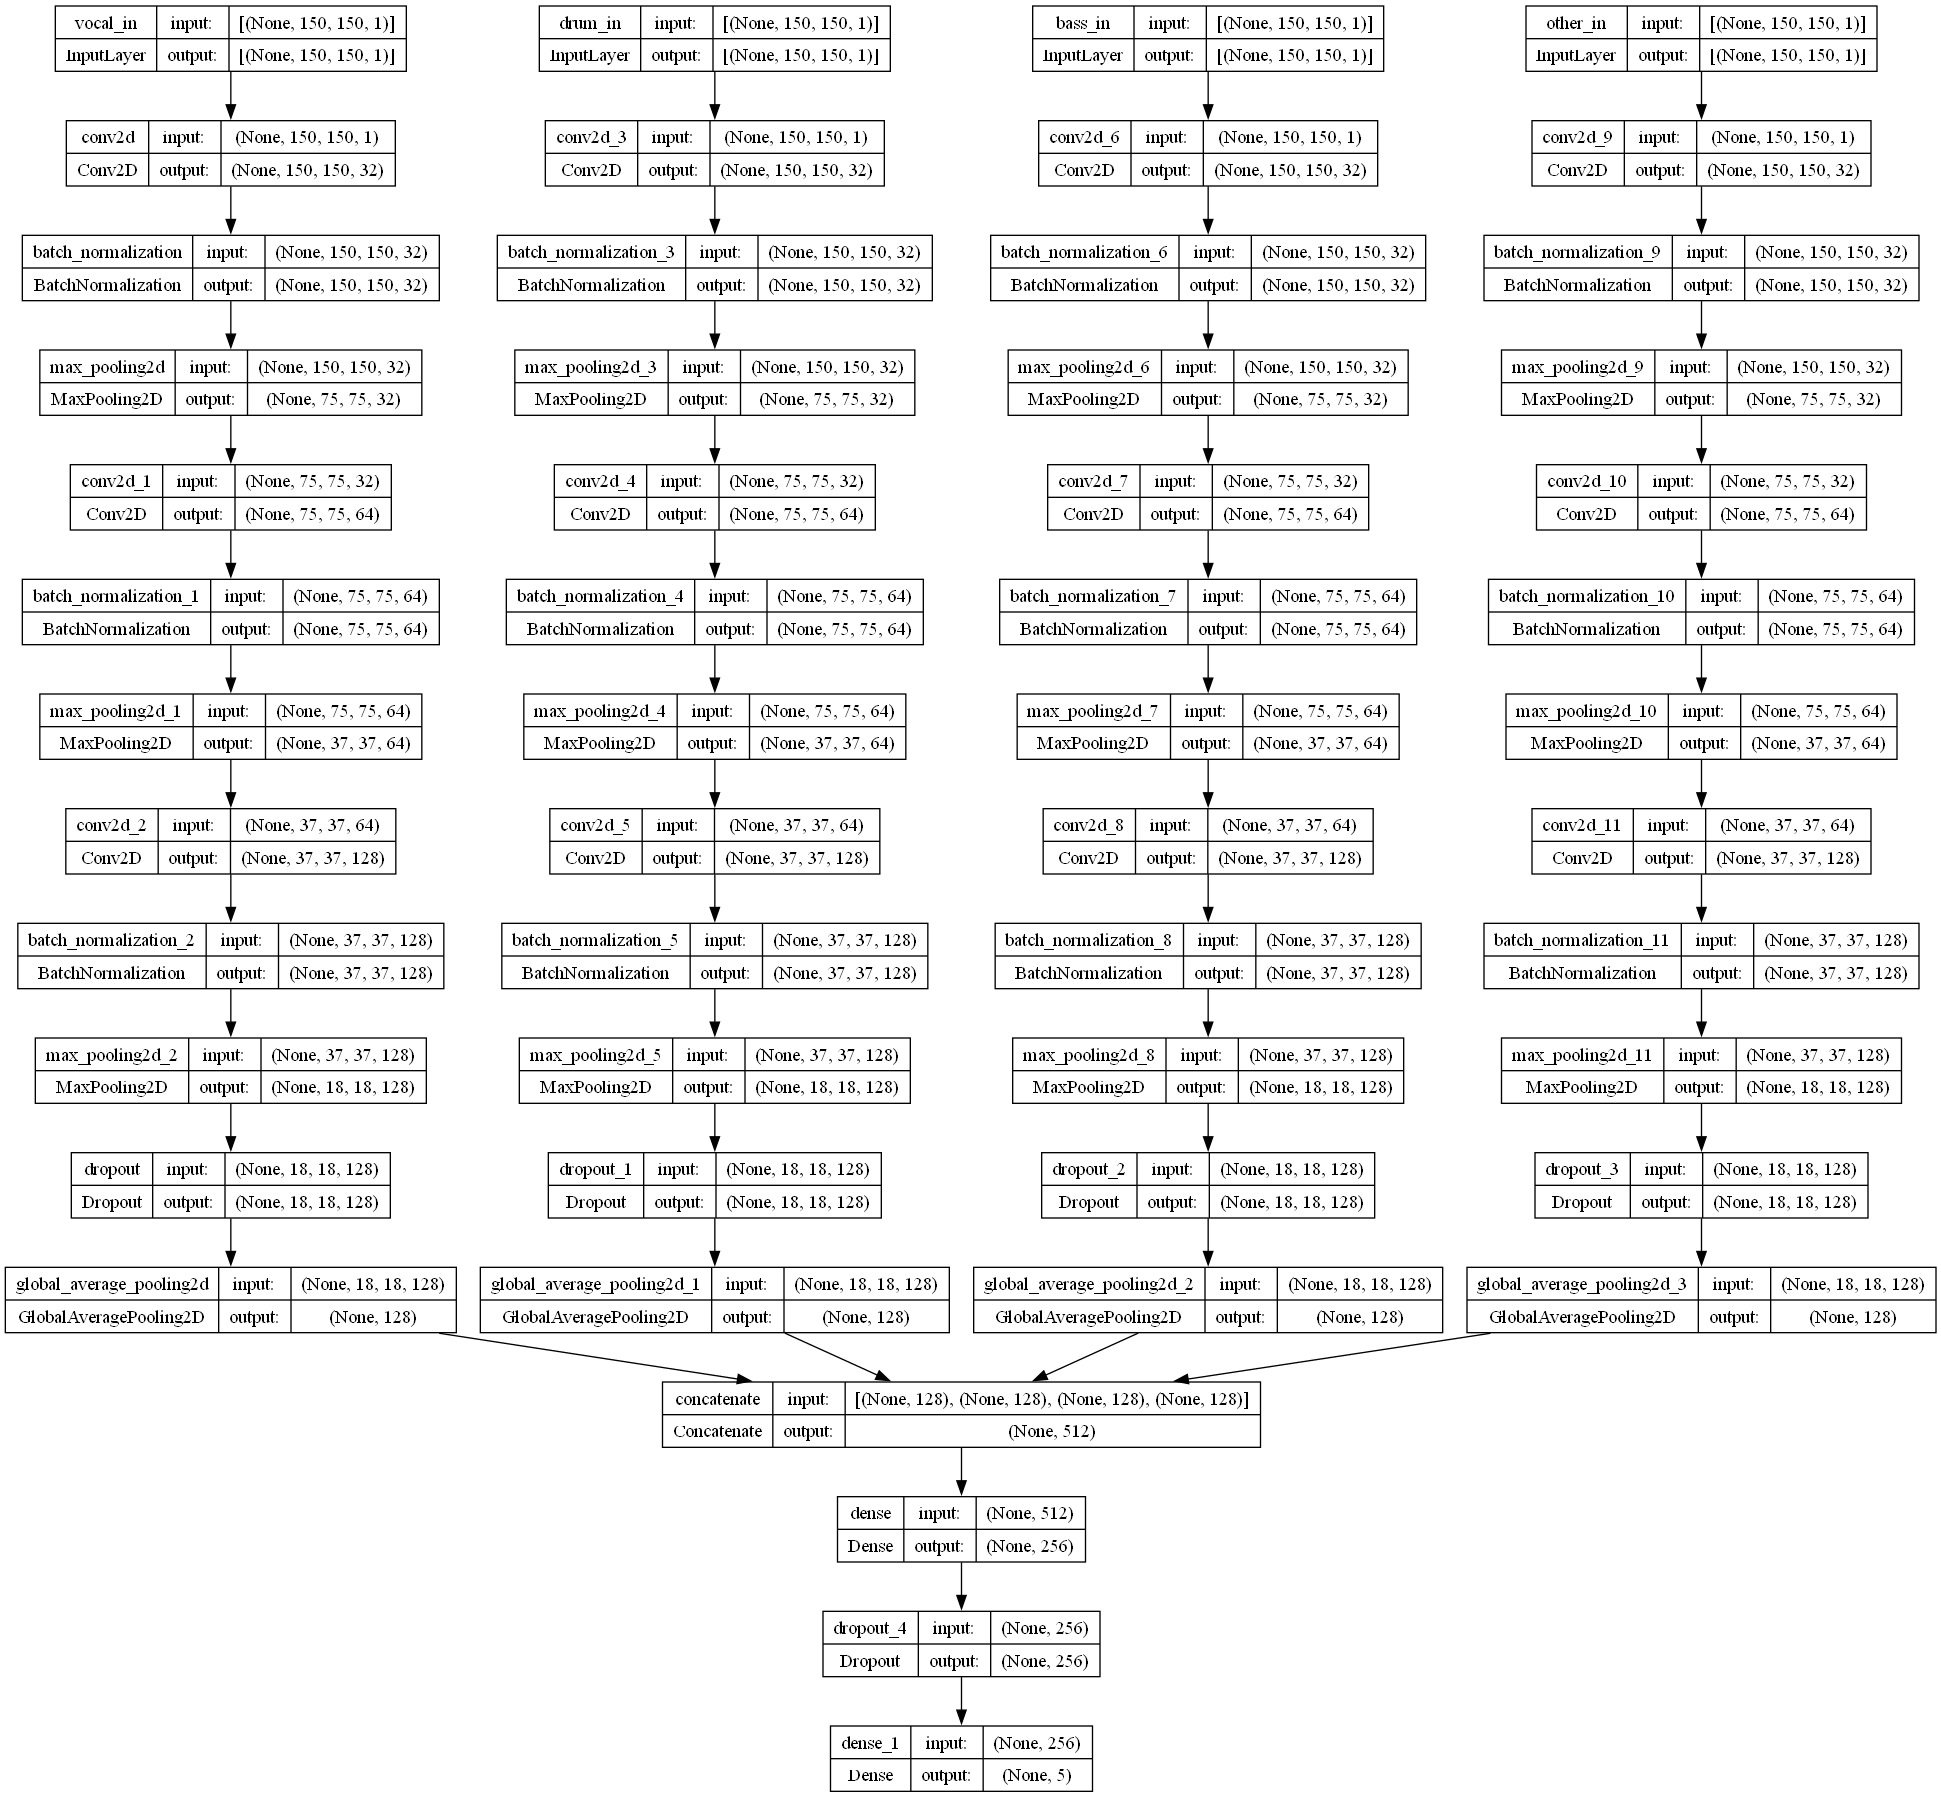

In [21]:
# Run this to save a high-quality image of your model's structure
tf.keras.utils.plot_model(
    model, 
    to_file='model_architecture.png', 
    show_shapes=True, 
    show_layer_names=True
)

## Architecture Visualization 

by Pydot python library and Graphiviz(windows exe and path added to users)

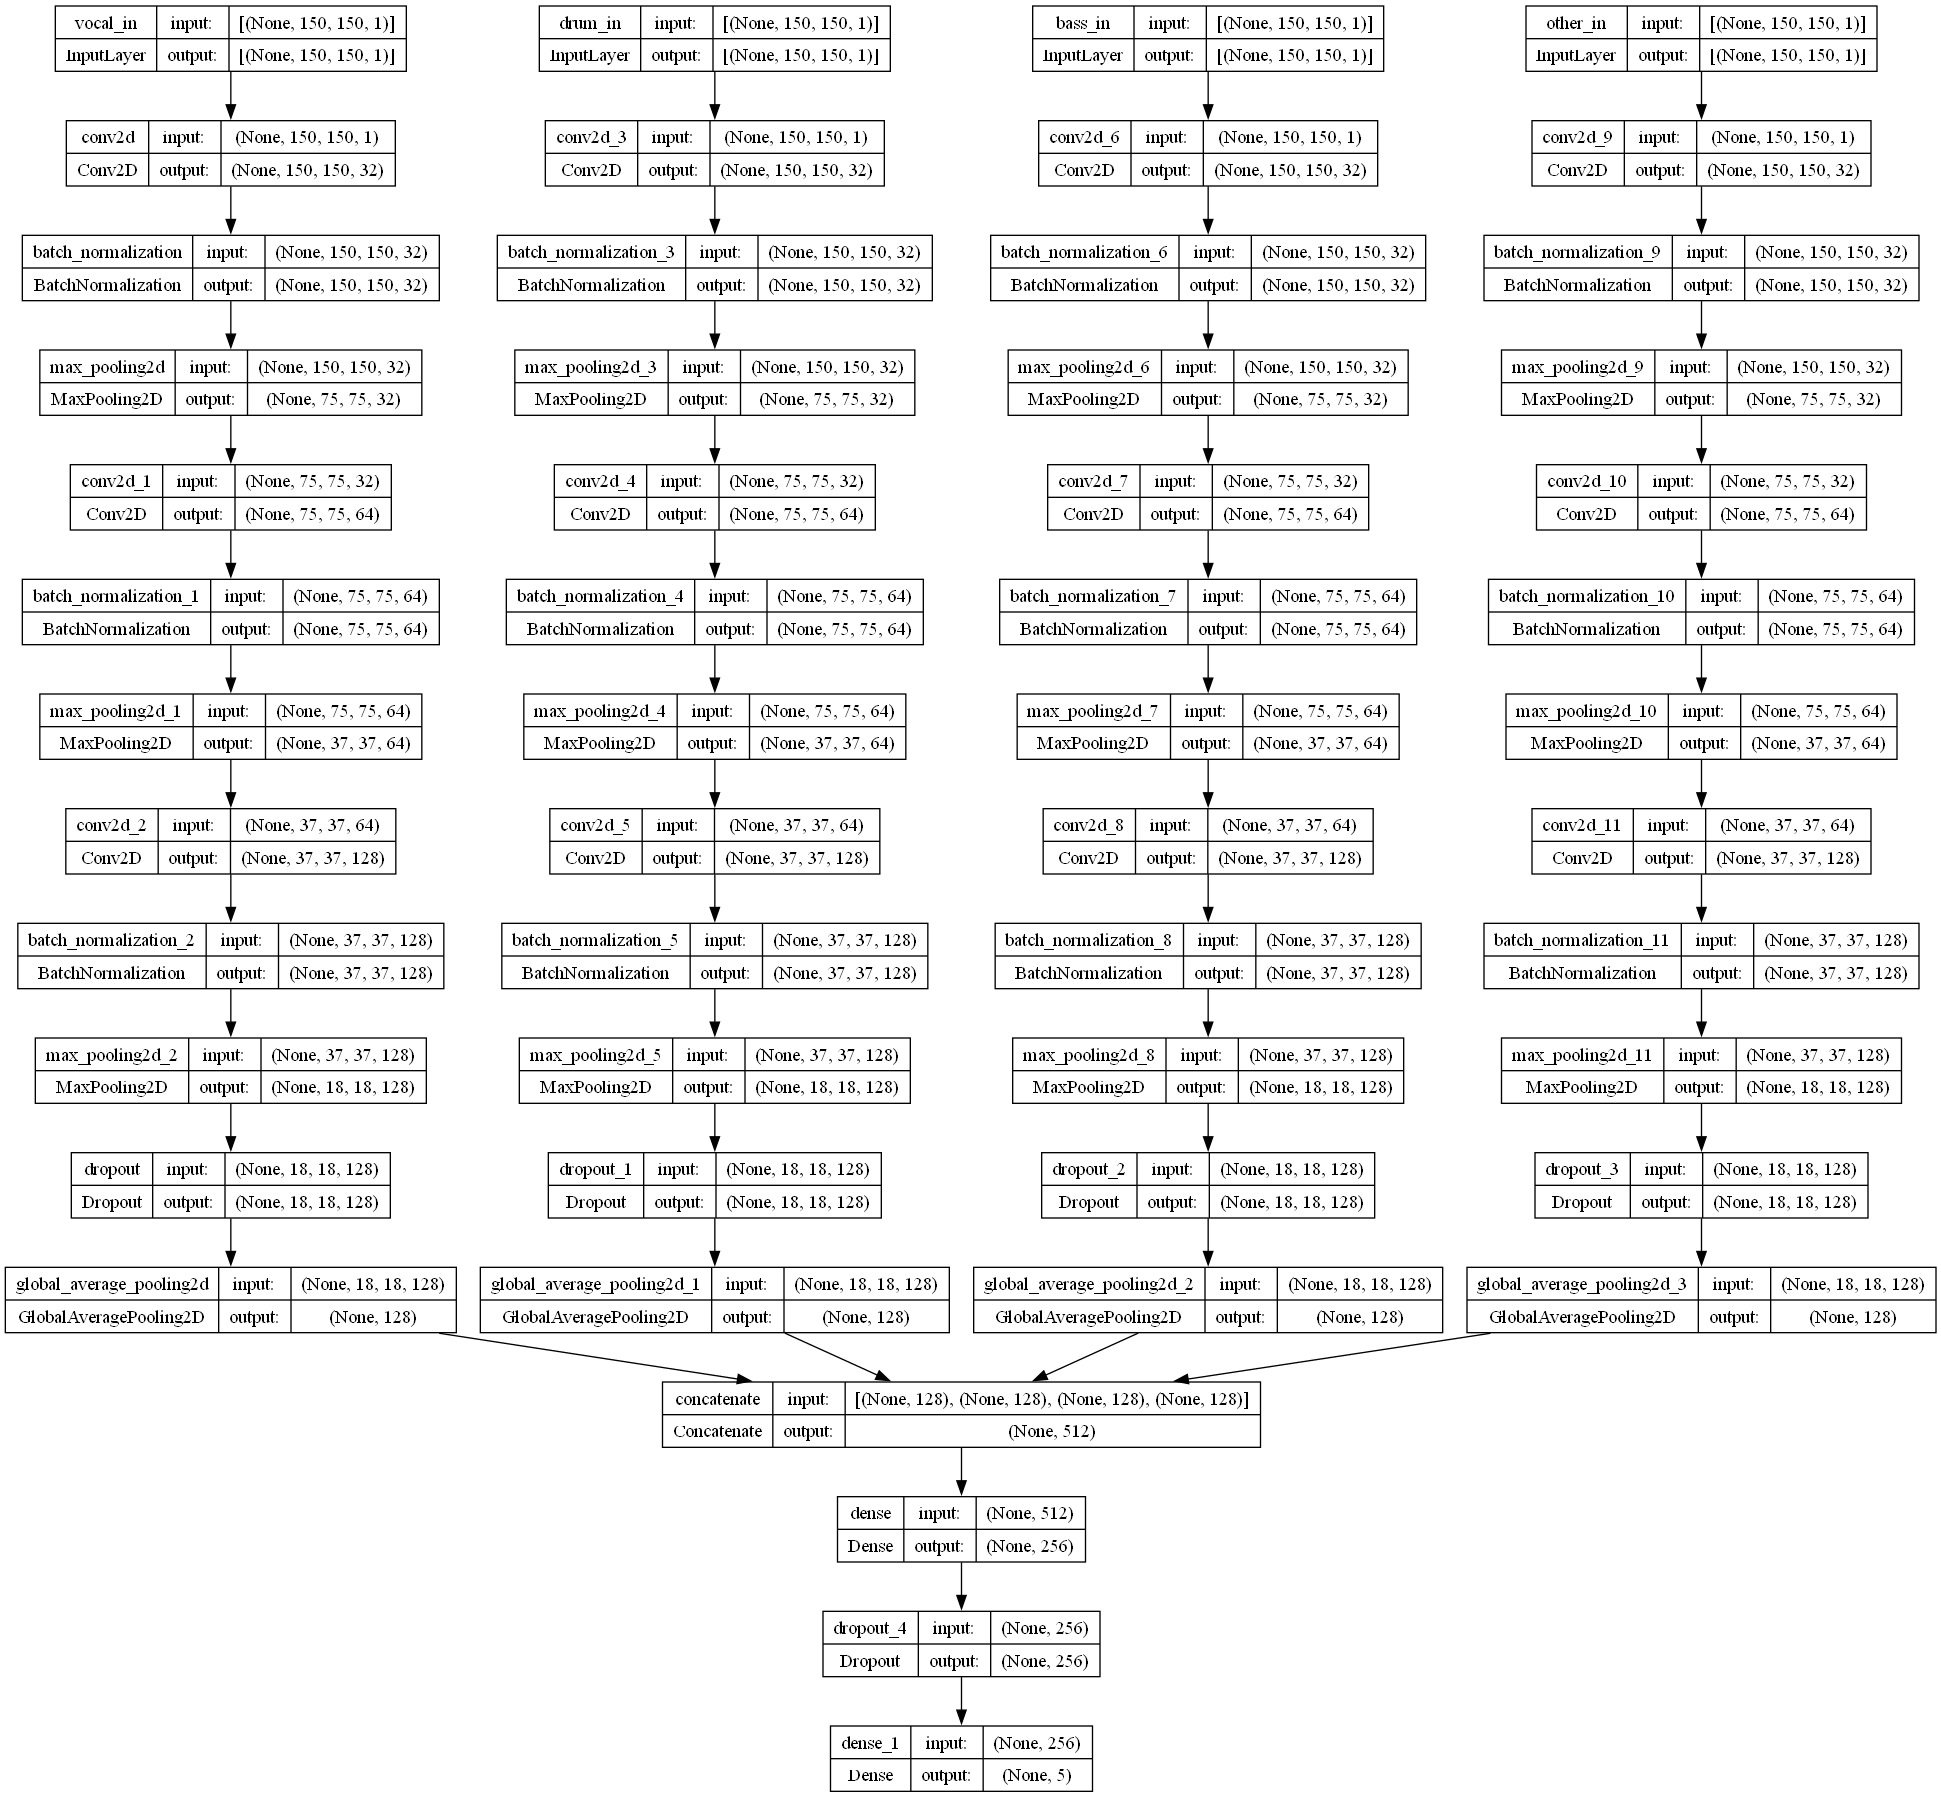

In [4]:
# Run this to save a high-quality image of your model's structure
tf.keras.utils.plot_model(
    model, 
    to_file='model_architecture.png', 
    show_shapes=True, 
    show_layer_names=True
)

## Labels save for future


In [6]:
import json
with open('genre_labels.json', 'w') as f:
    json.dump(classes, f)

## Important Features

Total params: 506,885
Trainable params: 505,093
Non-trainable params: 1,792

Training Time: ~40-50 mins (on RTX 3050)

Validation Accuracy: 97.06%

## Future Improvements

Every great AI project ends with ideas for version 2.0. Since you hit such high accuracy, your next steps could be:

Real-time Streamer: Detecting genres from a live microphone feed.

Mood Detection: Adding a second output to predict if the song is "Happy," "Sad," or "Devotional."

Instrument Identification: Predicting which specific instrument (Sitar vs. Veena) is dominant in the "Other" stem.